# Multiple Categories

This chapter examines how to compare categorical distributions across multiple groups. We will use jury-selection data from Alameda County and assess whether observed jury panels are consistent with random selection from the eligible population.

In [1]:
import pandas as pd
%matplotlib inline
path_data = "../../../../data/"
import matplotlib.pyplot as plt
plt.style.use("fivethirtyeight")
import numpy as np

## Jury Selection in Alameda County

The ACLU of Northern California studied the racial and ethnic composition of jury panels in Alameda County. The data compare the estimated distribution of eligible jurors with the distribution of people who appeared for jury service.

In [2]:
jury = pd.DataFrame({
    'Ethnicity': ['Asian/PI','Black/AA','Caucasian','Hispanic','Other'],
    'Eligible': [0.15,0.18,0.54,0.12,0.01],
    'Panels': [0.26,0.08,0.54,0.08,0.04]
})
jury

,Ethnicity,Eligible,Panels
0,Asian/PI,0.15,0.26
1,Black/AA,0.18,0.08
2,Caucasian,0.54,0.54
3,Hispanic,0.12,0.08
4,Other,0.01,0.04


Some groups are overrepresented and some are underrepresented in the panel data.

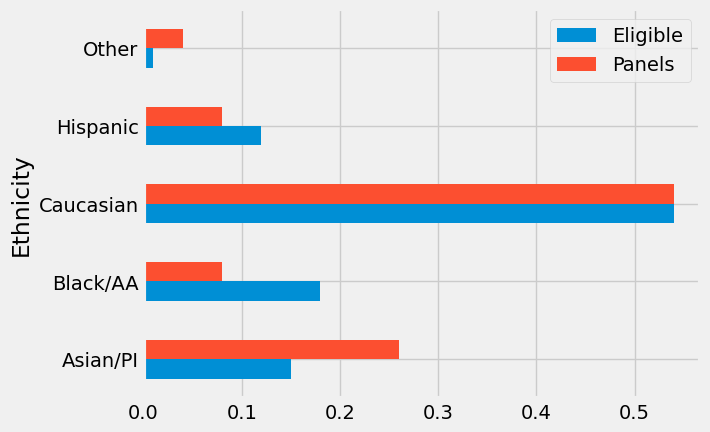

In [3]:
jury.set_index('Ethnicity')[['Eligible','Panels']].plot.barh()
plt.show()

## Comparison with Panels Selected at Random

We will compare the panel distribution to what we would expect from a random sample of 1,453 people drawn from the eligible population.

In [4]:
def sample_proportions(sample_size, proportions):
    categories = np.arange(len(proportions))
    sample = np.random.choice(categories, size=sample_size, p=proportions)
    counts = np.bincount(sample, minlength=len(proportions))
    return counts / sample_size

In [13]:
eligible_population = jury['Eligible'].to_numpy()
sample_distribution = sample_proportions(1453, eligible_population)
panels_and_sample = jury.copy()
panels_and_sample['Random Sample'] = sample_distribution
panels_and_sample

,Ethnicity,Eligible,Panels,Random Sample
0,Asian/PI,0.15,0.26,0.155540
1,Black/AA,0.18,0.08,0.171370
2,Caucasian,0.54,0.54,0.528562
3,Hispanic,0.12,0.08,0.134205
4,Other,0.01,0.04,0.010323


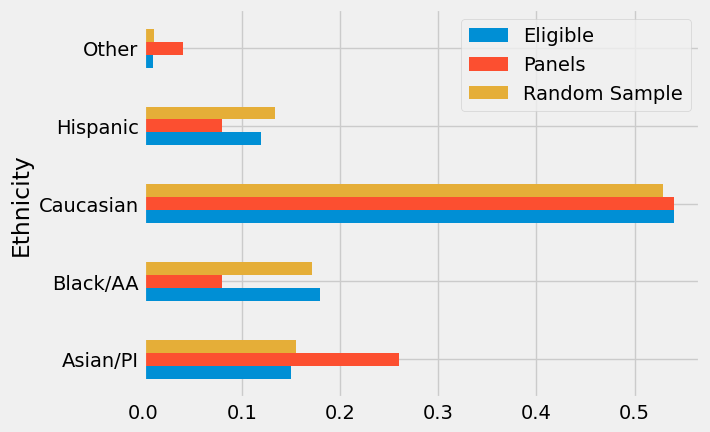

In [14]:
panels_and_sample.set_index('Ethnicity')[['Eligible','Panels','Random Sample']].plot.barh()
plt.show()

The random sample resembles the eligible population much more closely than the observed panels.

## A New Statistic: Total Variation Distance

To compare distributions quantitatively, we use the **total variation distance (TVD)**.

For two distributions, TVD is half the sum of the absolute differences between corresponding category proportions.

In [15]:
jury_with_diffs = jury.copy()
jury_with_diffs['Difference'] = jury['Panels'] - jury['Eligible']
jury_with_diffs

,Ethnicity,Eligible,Panels,Difference
0,Asian/PI,0.15,0.26,0.11
1,Black/AA,0.18,0.08,-0.10
2,Caucasian,0.54,0.54,0.00
3,Hispanic,0.12,0.08,-0.04
4,Other,0.01,0.04,0.03


In [16]:
jury_with_diffs['Absolute Difference'] = np.abs(jury_with_diffs['Difference'])
jury_with_diffs

,Ethnicity,Eligible,Panels,Difference,Absolute Difference
0,Asian/PI,0.15,0.26,0.11,0.11
1,Black/AA,0.18,0.08,-0.10,0.10
2,Caucasian,0.54,0.54,0.00,0.00
3,Hispanic,0.12,0.08,-0.04,0.04
4,Other,0.01,0.04,0.03,0.03


In [17]:
jury_with_diffs['Absolute Difference'].sum()/2

np.float64(0.14)

The observed TVD is 0.14.

In [18]:
def total_variation_distance(distribution_1, distribution_2):
    return np.sum(np.abs(distribution_1 - distribution_2)) / 2

In [19]:
total_variation_distance(jury['Panels'].to_numpy(), jury['Eligible'].to_numpy())

np.float64(0.14)

In [20]:
sample_distribution = sample_proportions(1453, eligible_population)
total_variation_distance(sample_distribution, eligible_population)

np.float64(0.012684101858224328)

## Simulating the Statistic Under the Model

We now simulate the TVD repeatedly under the assumption that panelists are selected at random from the eligible population.

In [21]:
def one_simulated_tvd():
    sample_distribution = sample_proportions(1453, eligible_population)
    return total_variation_distance(sample_distribution, eligible_population)

In [22]:
tvds = np.array([])
repetitions = 5000
for i in np.arange(repetitions):
    tvds = np.append(tvds, one_simulated_tvd())

## Assessing the Model of Random Selection

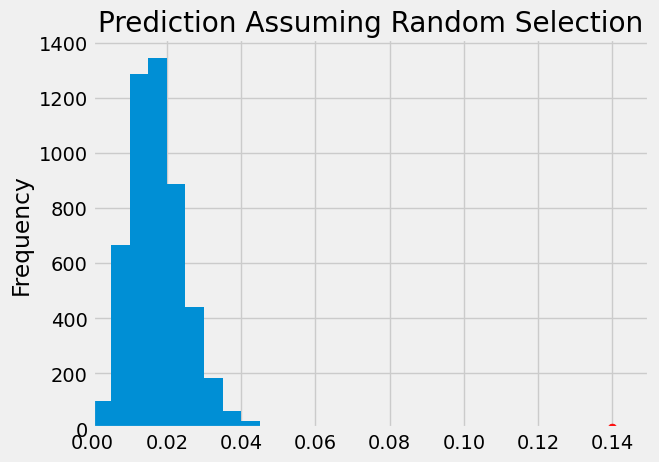

In [23]:
pd.DataFrame({'TVD': tvds})['TVD'].plot.hist(bins=np.arange(0,0.2,0.005))
plt.title('Prediction Assuming Random Selection')
plt.xlim(0,0.15)
plt.scatter(0.14,0,color='red',s=40)
plt.show()

The observed TVD of 0.14 lies far beyond the bulk of the simulated values. This provides evidence that the observed panel composition is not consistent with the model of random selection from the eligible population.

## Reasons for the Bias
As with most such analyses, ours doesn't say *why* the distributions are different. But those reasons are important to understand. If jury panels don't represent the population of eligible jurors, that can have a major effect on due process and the fairness of jury trials.

The ACLU report discusses several possible reasons for the discrepancies and suggests some remedies. Some are purely practical but have a big impact. For example, while we can take for granted the high quality of random sampling in Python, the panel selection used other software. The ACLU's examination revealed that the software didn't work well, contributing to biased selection. Using better software is a clear remedy.

More significantly, Alameda County jury panels are not selected from the entire eligible population. The [website](http://www.alameda.courts.ca.gov/pages.aspx/faqs) of the Superior Court of Alameda County says, "The objective of the court is to provide an accurate cross-section of the county's population. The names of jurors are selected at random from everyone who is a registered voter and/or has a driver's license or identification card issued by the Department of Motor Vehicles."

This process excludes eligible jurors who are not on those lists. Having state-issued ID or being registered to vote is most likely associated with income and hence also with race and ethnicity due to historical bias against Black and Hispanic communities. This leads to underrepresentation of those groups on the panels.

Those on the list have to be reached in order to inform them of their jury summons. But people in under-resourced communities don't always have fixed addresses. Out-of-date address records, lack of cross-checking with other lists such as those of the utilities, and so on can all contribute to biased selection.

Once reached, the potential panelists still have to be able to appear. The first day of jury service is not compensated, and compensation for subsequent days is \$15 per day. While employers are required by law to excuse employees who have jury duty, they are not required to provide compensation, and some employers don't. In a region as expensive as the Bay Area, this can become a reason for panelists not to respond to jury summons. Though jurors can be excused for severe economic hardship, even the process of requesting to be excused can be out of reach for some jurors. Across the Bay, city leaders in San Francisco are attempting to reduce this form of bias by piloting a [program](https://sftreasurer.org/new-ca-bill-pilots-higher-compensation-low-income-jurors-san-francisco) that provides compensation of \$100 per day to low-income jurors. 

## Data Quality
We have developed a technique that helps us decide whether one distribution looks like a random sample from another. But we should examine our data sources to better understand exactly what we can conclude from our analysis. Good data science includes a thoughtful examination of how the data were gathered. 

**Eligible Jurors.** It is important to keep in mind that not everyone is eligible to serve on a jury. On its [website](http://www.alameda.courts.ca.gov/pages.aspx/jury-duty-overview), the Superior Court of Alameda County says, "You may be called to serve if you are 18 years old, a U.S. citizen and a resident of the county or district where summoned. You must be able to understand English, and be physically and mentally capable of serving. In addition, you must not have served as any kind of juror in the past 12 months, nor have been convicted of a felony."

Though the Census is a natural source of demographic information, the Census doesn't collect data on all these categories. Thus the ACLU had to obtain the demographics of eligible jurors in some other way. 

What they used was a set of estimates that had been developed by a San Diego State University professor for an Alameda County trial in 2002. Those estimates were based on the 2000 Census and also took into account the criteria required for eligibility as a juror.

So we have to keep in mind that the distribution that we used for the eligible population is itself an estimate and is therefore subject to error. Moreover, as the ACLU noted, using estimates based on the 2000 Census for populations in 2010 might not be accurate due to the changing demographics in California.

Thus the distribution used for the population of eligible jurors might not be accurate.

**Panels.** It is not clear from the report exactly how the 1453 panelists were classified into the different ethnic categories. The report says only that "attorneys ... cooperated in collecting jury pool data". 

Significant social, cultural, and political factors affect who gets classified or self-classifies into each ethnic category. It is also not clear if the definitions of those categories in the panels were the same as those used in the estimates of the distribution of eligible jurors. This raises questions about the correspondence between the two distributions being compared.

Moreover, the data on panelists was obtained from those who reported for service. As we have discussed, not all panelists do so. The reasons for not reporting are associated with race and ethnicity, and disproportionately affect panelists from under-resourced communities. 

Responding to jury summons is required by law. But as the ACLU noted, at the time of the study Alameda County did not have an effective process for following up on prospective jurors who had been called but had failed to appear. The ACLU recommended the creation of "a failure to appear program that requires, at a minimum, the issuance of a second notice to prospective jurors." 

Indeed, following up on non-respondents would reduce bias. For our analysis, we must acknowledge that we don't have the data needed to fill in the demographic information for panelists who were selected but did not report for service.

## Conclusion

Because of the discussion above, it is important for us to be precise about what we can conclude from our analysis.

- We can conclude that the distribution provided for the panelists who reported for service does not look like a random sample from the estimated distribution in the eligible population.

Our discussion, like the discussion in the ACLU report, sets out reasons for some of the differences observed between the two distributions and for why summoned panelists might nor report. Almost all the reasons have their roots in historical racial bias in society, and are examples of the lasting negative consequences of that bias.